<a href="https://colab.research.google.com/github/eahernandezrangel-art/LabAvanzado/blob/main/Proyecto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto 2: Uso de redes neuronales para identificar que conjunto de variables obtenidas mediante analisis de bandas de FTIR discrimina menjor entre pacientes sanos y anemicos

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.neural_network import MLPClassifier

In [57]:
#Cargamos las bases ,estas bases contiene el area de cada banda encontrada en el espectro del suero humano, el area de las subcompuestos proteicos
#de la banda amidaI obtenidas mediante una desconvolucion gaussiana y la combinacion de estas dos bases
areas=pd.read_excel('AreaFTIR_resumen.xlsx')
multigauss=pd.read_excel('multigauss_FTIR.xlsx')
total=pd.read_excel('Areas_con_multigauss_FTIR.xlsx')

#Vemos las dimensiones de la base
print(areas.shape)
print(multigauss.shape)
print(total.shape)

#veamos si los grupos estan balanceados
areas['Grupo'].value_counts()



(33, 12)
(33, 35)
(33, 45)


,count
Grupo,
anemico,18
asume,8
sano,7


In [58]:
#Con lo anterior  podemos observar que algunas bases de datos contienen un numero
#comparable  o incluso superior al número de muestras disponibles, por lo que se
# empleara un Analisis de Componentes Principales para reducir dimensionalidad y explorar la estructura
# de los datos y ver que variables verdaderamente describen a las muestras

#Como tenemos 3 bases de datos nos conviene crear una funcion general para el PCA, por lo qu
def hacer_pca(df, nombre_base):

    # Separar variables y grupos
    X = df.drop(columns=["Muestra", "Grupo"])
    y = df["Grupo"]

    # Escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Varianza explicada
    print(f"\n===== {nombre_base} =====")
    print("Variables:", X.shape[1])

    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var:.4f}")

    # Gráfica varianza acumulada
    plt.figure(figsize=(7,4))

    plt.plot(
        np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_),
        "o-"
    )

    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza acumulada")
    plt.title(f"PCA - {nombre_base}")
    plt.grid()
    plt.show()

    # Gráfica PC1 vs PC2
    plt.figure(figsize=(7,6))

    for grupo in y.unique():
        mask = y == grupo

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=80,
            label=grupo
        )

    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    plt.title(f"PCA - {nombre_base}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return X, y, X_scaled, pca, X_pca



===== Areas de FTIR =====
Variables: 10
PC1: 0.8010
PC2: 0.1403
PC3: 0.0264
PC4: 0.0196
PC5: 0.0049
PC6: 0.0042
PC7: 0.0018
PC8: 0.0012
PC9: 0.0005
PC10: 0.0001


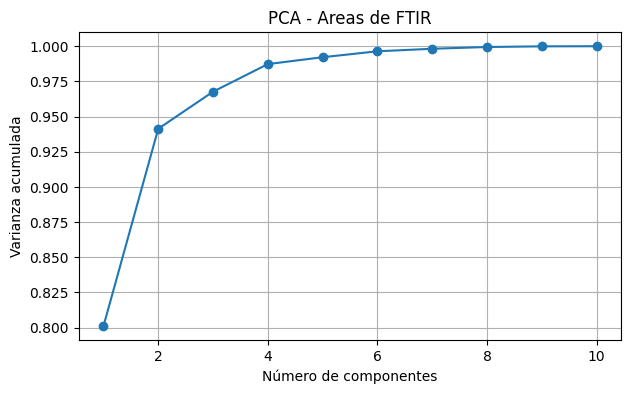

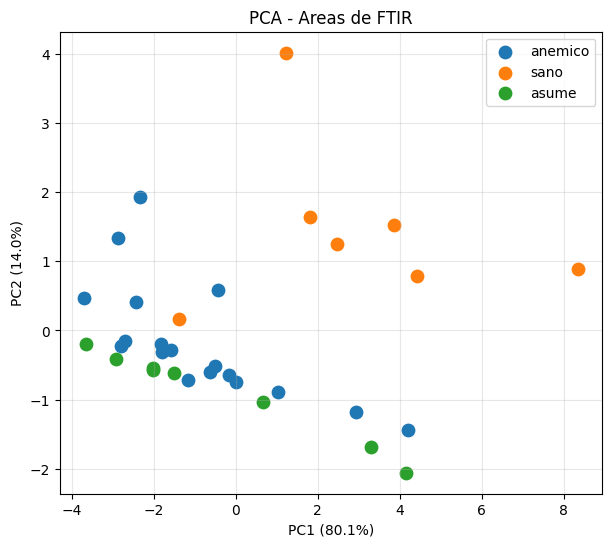

In [59]:
#Teniendo el general ,ahora podemos definir para cada base

#PCA solo para areas de FTIR
X_areas, y_areas, X_scaled_areas, pca_areas, X_pca_areas = hacer_pca(areas, "Areas de FTIR")


In [60]:
#veamos a que corresponde cada componente para areas
cargas = pd.DataFrame(
    pca_areas.components_.T,
    index=X_areas.columns,
    columns=[
        f"PC{i+1}"
        for i in range(
            len(X_areas.columns)
        )
    ]
)

cargas

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Amida I,0.349807,-0.034128,-0.211149,0.039871,-0.121786,-0.193246,0.226611,-0.273337,-0.608511,-0.530820
Amida II,0.349207,-0.043816,-0.217575,0.096836,-0.101839,-0.334589,0.061056,-0.137372,-0.198957,0.796815
Amida III,0.348341,-0.061358,-0.136373,0.143353,-0.262406,-0.415481,-0.174090,-0.165120,0.683716,-0.263106
C-H lípidos/proteínas,0.335764,-0.203800,-0.138214,-0.139934,0.684370,0.247915,-0.397448,-0.343037,0.039213,-0.006416
CH₂ / CH₃ deformación,0.340257,-0.109815,0.369738,0.184388,0.211518,-0.299755,-0.269507,0.671750,-0.188616,-0.086077
CO₂ atmosférico,0.144303,0.734805,0.113435,-0.592658,0.107250,-0.247637,-0.044117,-0.011443,0.013985,-0.005214
Fosfatos / C-O / carbohidratos,0.311075,-0.199047,0.780770,-0.135087,-0.164382,0.172629,0.251678,-0.325653,0.063528,0.074248
Huella digital baja,0.226423,0.592351,0.064550,0.679885,0.098395,0.327792,0.073399,-0.080126,0.048768,0.011299
O-H / N-H,0.343883,-0.092614,-0.273470,-0.185117,0.205504,0.209373,0.676472,0.385653,0.267485,-0.012353
Sobretonos / combinación,0.344558,0.023269,-0.179579,-0.221130,-0.549909,0.533251,-0.394618,0.221133,-0.085970,0.028643


In [61]:
cargas["PC1"].sort_values(
    key=np.abs,
    ascending=False
)

,PC1
Amida I,0.349807
Amida II,0.349207
Amida III,0.348341
Sobretonos / combinación,0.344558
O-H / N-H,0.343883
CH₂ / CH₃ deformación,0.340257
C-H lípidos/proteínas,0.335764
Fosfatos / C-O / carbohidratos,0.311075
Huella digital baja,0.226423
CO₂ atmosférico,0.144303



===== Areas de FTIR =====
Variables: 8
PC1: 0.9402
PC2: 0.0359
PC3: 0.0104
PC4: 0.0083
PC5: 0.0024
PC6: 0.0019
PC7: 0.0007
PC8: 0.0001


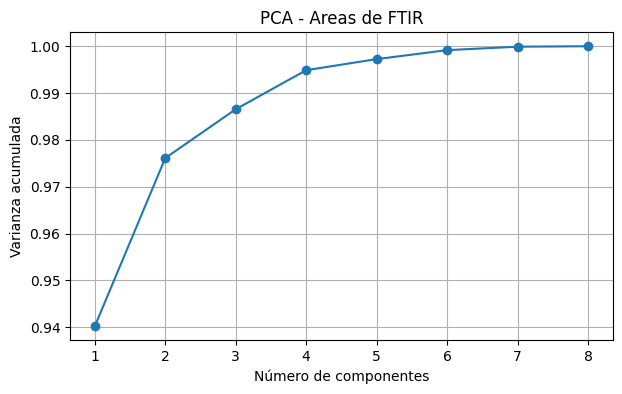

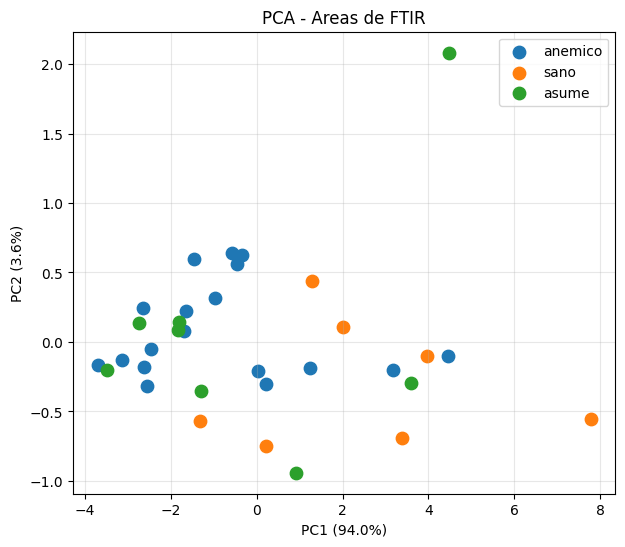

In [62]:
#Vemos que el primer componente explica aproximadamente un 80%e la varianza
#total y presentó contribuciones similares de todas las regiones espectrales consideradas.
# Esto indica que la principal fuente de variacion entre muestras corresponde a cambios
#globales en la intensidad de absorcion de las bandas FTIR asociadas a proteinas,
#lipidos y carbohidratos sericos.El segundo componente principal explico un 14% adicional
#de la varianza y estuvo dominado principalmente por las regiones asociadas al CO₂ atmosférico
# y la huella digital baja que son componentes que dominan principalemente el ambiente experimental
# por lo que realizaremos ahora un pca de la misma base excluyendo datoa ambientales

columnas_quitar=[
    'CO₂ atmosférico',
    'Huella digital baja',
    ]
areas_limpias=areas.drop(columns=columnas_quitar)

X_areas_limpias, y_areas_limpias, X_scaled_areas_limpias, pca_areas_limpias, X_pca_areas_limpias = hacer_pca(areas_limpias, "Areas de FTIR")


In [ ]:
# Apesar del cambio en las columnas continuamos observando que el primer componente
# sigue explicando , ahora el 94% de la varianza total de la muestra.Este comportamiento
# indica una fuerte correlacion entre las areas integradas, sugiriendo que la principal
#fuente de variacion corresponde a cambios globales en la intensidad espectral más que a
#modificaciones especificas de determinadas bandas. Es decir, no nos esta dando informacion
# sobre la estructura quimica de la muestra .


===== Multigauss =====
Variables: 33
PC1: 0.4353
PC2: 0.1675
PC3: 0.1521
PC4: 0.0606
PC5: 0.0516
PC6: 0.0423
PC7: 0.0305
PC8: 0.0156
PC9: 0.0130
PC10: 0.0087
PC11: 0.0061
PC12: 0.0053
PC13: 0.0038
PC14: 0.0023
PC15: 0.0016
PC16: 0.0012
PC17: 0.0011
PC18: 0.0005
PC19: 0.0004
PC20: 0.0002
PC21: 0.0002
PC22: 0.0001
PC23: 0.0000
PC24: 0.0000
PC25: 0.0000
PC26: 0.0000
PC27: 0.0000
PC28: 0.0000
PC29: 0.0000
PC30: 0.0000
PC31: 0.0000
PC32: 0.0000
PC33: 0.0000


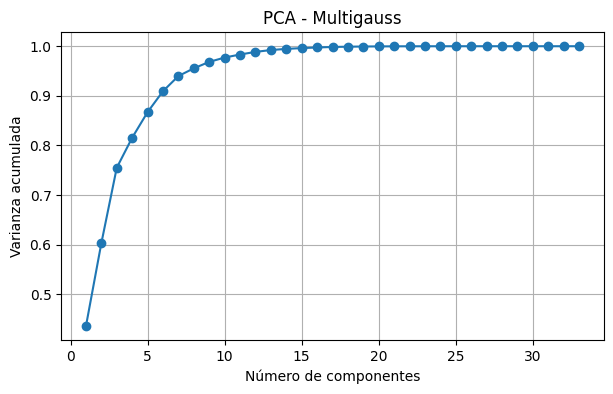

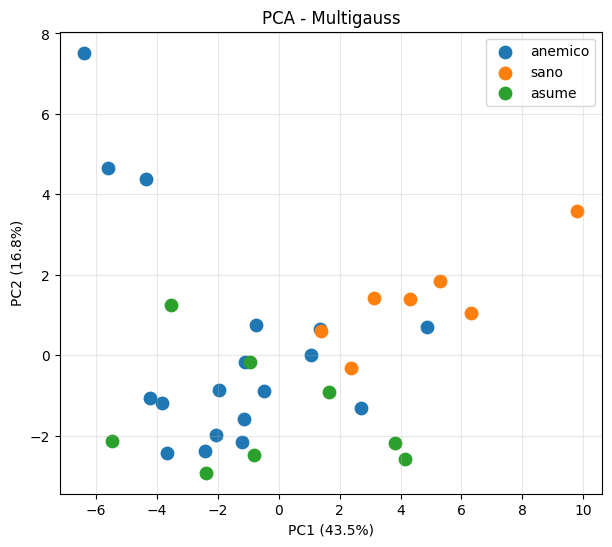

In [63]:
#PCA para multigauss
X_multigauss, y_multigauss, X_scaled_multigauss, pca_multigauss, X_pca_multigauss = hacer_pca(multigauss, "Multigauss")

In [64]:
#veamos a que corresponde cada componente para multigauss
cargas_multigauss = pd.DataFrame(
    pca_multigauss.components_.T,
    index=X_multigauss.columns,
    columns=[
        f"PC{i+1}"
        for i in range(
            len(X_multigauss.columns)
        )
    ]
)

cargas_multigauss

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
Area_total_gauss,0.239566,0.088467,0.157757,-0.037303,-0.039464,0.008473,0.025831,0.028195,0.021251,-0.031861,...,-0.070257,-0.036343,0.018944,0.008187,0.010900,0.000000e+00,0.000000e+00,0.000000e+00,-0.000000e+00,9.421482e-01
Area_β-sheet intermolecular_1618,0.236502,0.075988,0.162448,0.023004,0.001813,0.061430,0.109254,-0.040300,-0.047218,-0.049561,...,-0.137372,-0.047025,-0.048407,0.038156,0.044092,2.171886e-01,2.307892e-01,-2.229805e-01,4.218198e-02,-1.637592e-01
Mu_β-sheet intermolecular_1618,-0.070090,0.148340,-0.003953,-0.112605,0.457701,-0.107557,0.572064,0.023662,0.364322,-0.082353,...,0.040311,0.030563,-0.026002,0.135890,-0.066144,-1.393560e-16,1.325819e-15,-2.116092e-16,-1.947785e-15,3.157197e-16
Sigma_β-sheet intermolecular_1618,0.141187,0.105901,-0.068199,0.434972,0.176087,0.124646,0.180355,-0.303468,0.299934,0.186478,...,-0.088633,0.040718,0.025791,-0.013975,0.008982,3.427556e-16,-1.151536e-16,-1.548382e-16,2.262640e-17,-2.567391e-16
Area_β-sheet_1628,0.140698,-0.075864,0.330492,-0.000287,0.158591,0.121209,-0.096232,-0.176938,-0.012451,-0.062088,...,-0.197461,-0.042861,0.108076,-0.038010,0.029398,1.100561e-01,1.169479e-01,-1.129910e-01,2.137489e-02,-8.298179e-02
Mu_β-sheet_1628,-0.117782,-0.223221,0.237925,-0.046097,-0.023374,-0.142550,-0.259237,0.101222,0.470148,-0.010068,...,0.122361,-0.081684,0.039662,0.065151,-0.065572,-8.244980e-17,7.305092e-16,-8.036818e-16,-4.762591e-15,7.216450e-16
Sigma_β-sheet_1628,-0.000610,-0.206289,0.266643,-0.049544,0.244378,0.214014,-0.361114,-0.204061,0.037652,-0.123436,...,0.079215,-0.079526,0.004974,0.068485,-0.004515,-1.176281e-16,-1.535076e-16,-3.314850e-16,4.669054e-16,2.879641e-16
Area_β-sheet_1638,0.217794,0.163472,0.090691,-0.005398,-0.225781,-0.067699,0.037923,0.154609,0.135933,-0.014115,...,-0.245988,-0.085765,0.066062,-0.240396,0.178335,1.760264e-01,1.870494e-01,-1.807206e-01,3.418753e-02,-1.327231e-01
Mu_β-sheet_1638,-0.155664,-0.113451,0.303574,0.176261,-0.107714,-0.005043,-0.007810,0.114170,0.140260,-0.043734,...,-0.173434,0.316047,-0.152091,-0.264124,0.088895,-9.348278e-16,-2.318467e-15,1.582861e-15,8.845520e-15,-1.498801e-15
Sigma_β-sheet_1638,0.114113,0.164207,-0.133506,0.397275,-0.313959,-0.097370,0.060699,-0.016250,-0.128216,0.144102,...,0.087748,-0.111739,0.018824,0.041295,-0.062681,-1.735530e-16,1.384034e-15,-3.715899e-16,-5.277702e-15,7.771561e-16


In [65]:
cargas_multigauss["PC1"].sort_values(
    key=np.abs,
    ascending=False
)

,PC1
Area_α-helix_1657,0.253322
Area_alpha_total,0.252062
Area_β-turn_1681,0.250952
Area_α-helix_1650,0.244769
Area_total_gauss,0.239566
Area_β-sheet intermolecular_1618,0.236502
Area_beta_total,0.229243
Area_turn_total,0.225392
Area_β-sheet_1638,0.217794
Alpha/Beta,0.206551


In [66]:
cargas_multigauss["PC2"].sort_values(
    key=np.abs,
    ascending=False
)

,PC2
Sigma_β-turn_1673,0.364394
Turn/Beta,0.362801
Turn/Total,0.358451
Mu_β-turn_1673,-0.356442
Sigma_α-helix_1657,-0.256679
Mu_β-sheet_1628,-0.223221
Area_β-turn_1673,0.211144
Sigma_β-sheet_1628,-0.206289
Alpha/Total,-0.173329
Mu_β-sheet_1691,0.166524


In [ ]:
# Aqui ya vemos algo mucho mas interesante a nivel estructural,el primer componente
# esta dominado por informacion  asociada al contenido global de alpha helice y beta plegable
#y areas totales de la banda Amida I, mientras que el segundo componente estuvo fuertemente
# influenciado por parametros relacionados con estructuras beta turn y sus proporciones relativas.
#Esto ya nos sugiere  que la principal fuente de variabilidad entre las muestras estan asociados
# tanto a cambios globales en la estructura secundaria proteica, como a modificaciones especificass
# en la contribucion de giros beta.


===== Total =====
Variables: 43
PC1: 0.5008
PC2: 0.1455
PC3: 0.1321
PC4: 0.0480
PC5: 0.0437
PC6: 0.0388
PC7: 0.0235
PC8: 0.0130
PC9: 0.0105
PC10: 0.0100
PC11: 0.0085
PC12: 0.0056
PC13: 0.0048
PC14: 0.0040
PC15: 0.0029
PC16: 0.0021
PC17: 0.0017
PC18: 0.0013
PC19: 0.0010
PC20: 0.0008
PC21: 0.0004
PC22: 0.0004
PC23: 0.0002
PC24: 0.0002
PC25: 0.0001
PC26: 0.0001
PC27: 0.0001
PC28: 0.0000
PC29: 0.0000
PC30: 0.0000
PC31: 0.0000
PC32: 0.0000
PC33: 0.0000


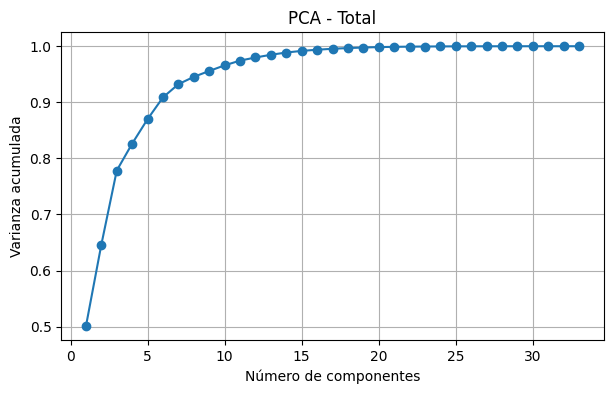

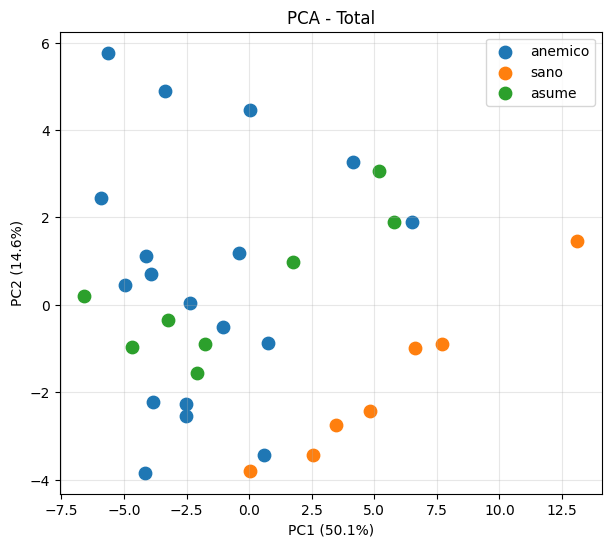

In [67]:
#PCA combinado
X_total, y_total, X_scaled_total, pca_total, X_pca_total = hacer_pca(total, "Total")

In [68]:
#veamos a que corresponde cada componente para la base con todo
cargas_total = pd.DataFrame(
    pca_total.components_.T,
    index=X_total.columns,
    columns=[
        f"PC{i+1}"
        for i in range(
            len(pca_total.components_)
        )
    ]
)

cargas_total

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
Amida I,0.208916,0.092937,0.010141,-0.005766,-0.017340,-0.022078,0.018671,0.030939,0.046461,-0.012737,...,0.035030,-0.023651,-0.056555,-0.099599,-0.052033,-0.016565,0.002873,-0.068894,-0.016738,-0.160808
Amida II,0.206292,0.106415,0.014844,-0.028633,-0.026866,-0.020822,0.027788,0.050379,0.071658,-0.015204,...,0.025354,0.006424,0.166019,-0.207917,-0.038376,-0.152989,-0.089204,0.369322,-0.186873,0.464706
Amida III,0.204101,0.113900,0.017897,-0.047176,-0.016132,-0.021950,0.005177,0.072892,0.067230,0.034453,...,-0.300593,0.187971,0.435584,0.180762,0.044858,0.317303,0.118207,0.132377,0.433273,-0.076684
C-H lípidos/proteínas,0.193919,0.146912,-0.057073,-0.048197,0.040512,-0.030175,-0.010093,-0.137954,-0.041909,-0.035101,...,0.369147,0.117460,-0.107440,0.298563,-0.203940,0.445222,-0.273635,0.229814,0.083615,0.060701
CH₂ / CH₃ deformación,0.194988,0.118555,0.009964,-0.082215,0.005107,-0.003678,-0.009853,-0.046289,-0.016040,0.302615,...,-0.120910,-0.145859,0.320614,0.136198,0.233196,-0.023186,-0.022288,-0.208622,-0.169155,-0.123164
CO₂ atmosférico,0.100501,-0.158281,0.130414,0.116714,-0.357054,0.166606,-0.026920,0.067600,-0.305645,-0.279331,...,0.038799,0.057978,0.026050,-0.091349,-0.015924,0.003375,-0.005649,-0.025235,0.003740,-0.012543
Fosfatos / C-O / carbohidratos,0.174818,0.131031,-0.015157,-0.010821,0.084683,0.024034,-0.006716,-0.159782,-0.103897,0.505831,...,0.024149,-0.007142,-0.286898,-0.050652,-0.167092,-0.067060,-0.014910,0.143472,0.057934,0.052130
Huella digital baja,0.149853,-0.132162,0.148180,-0.029417,-0.254626,0.122148,-0.033619,0.212867,-0.083515,-0.131099,...,0.106263,-0.060558,-0.008024,-0.070620,0.031787,0.063165,0.033588,0.029136,0.029969,0.005620
O-H / N-H,0.203078,0.110638,-0.022640,-0.015327,0.005307,-0.073979,0.025443,-0.037736,-0.038192,-0.107986,...,0.003916,0.072085,-0.010459,0.279802,-0.235408,-0.372963,0.369692,0.151294,0.131546,0.055770
Sobretonos / combinación,0.205270,0.080440,0.006621,-0.030696,-0.017118,0.001697,-0.005852,0.079152,-0.112849,-0.105595,...,-0.280802,-0.063485,0.060857,0.298300,0.130960,0.097290,-0.268792,-0.055906,-0.190553,0.027232


In [69]:
cargas_total["PC1"].sort_values(
    key=np.abs,
    ascending=False
)

,PC1
Area_alpha_total,0.212398
Area_α-helix_1657,0.211800
Area_β-turn_1681,0.210617
Amida I,0.208916
Area_total_gauss,0.208841
Area_α-helix_1650,0.207437
Amida II,0.206292
Sobretonos / combinación,0.205270
Area_β-sheet intermolecular_1618,0.205245
Amida III,0.204101


In [70]:
cargas_total["PC2"].sort_values(
    key=np.abs,
    ascending=False
)

,PC2
Mu_α-helix_1650,0.261484
Alpha/Total,-0.257644
Alpha/Beta,-0.254961
Sigma_α-helix_1657,-0.253527
Mu_β-sheet_1638,0.241808
Sigma_α-helix_1650,-0.241787
Beta/Total,0.231759
Area_β-sheet_1691,0.226548
Sigma_β-turn_1681,-0.226157
Area_β-sheet_1628,0.210159


In [71]:
cargas_total["PC3"].sort_values(
    key=np.abs,
    ascending=False
)

,PC3
Turn/Beta,0.376881
Turn/Total,0.338069
Sigma_β-turn_1673,0.329367
Mu_β-turn_1673,-0.319436
Sigma_β-sheet_1628,-0.290133
Mu_β-sheet_1628,-0.274237
Area_β-sheet_1628,-0.203172
Mu_β-sheet_1638,-0.198179
Sigma_β-sheet_1638,0.197115
Sigma_α-helix_1657,-0.192300


In [ ]:
#Aqui obsevamos algo tambien interesante, en este caso dominan 3 componentes, donde
#el primer componente podemos asociarlo con las areas de las bandas de AmidaI,II yIII ,
# asi como el contenido total de alpha helice y el area total de descovolucion gaussiana.
#El segundo componente esta dominado por relaciones estructurales como lo es Alpha/total
#Alpha/Beta y Beta/Total, indicando que este eje describe cambios relativos entre alpha helice
# y beta plegable. Finamete el tercer componente  nos habla de la relacionado con los giros,
# ademas del desplazamiento y anchuras corresondientes por picos.Es decir nos esta dando una
# vision mas global de los cambios estructurales relacionando directamente los picos proteicos
#principales que son los amida con el cambio subestructural que e presenta por muestra incluyendo
# relacionando cambios en el desplazamiento y anchura de banda.


In [72]:
#Hagamos una tabla de varianza acumulada
def resumen_varianza(pca, nombre_base):
    var_acum = np.cumsum(pca.explained_variance_ratio_)

    return pd.DataFrame({
        'Base': nombre_base,
        'PC': np.arange(1, len(var_acum) + 1),
        'Varianza explicada': pca.explained_variance_ratio_,
        'Varianza acumulada': var_acum
    })

tabla_varianza = pd.concat([
    resumen_varianza(pca_areas, "Áreas FTIR"),
    resumen_varianza(pca_multigauss, "Multigauss"),
    resumen_varianza(pca_total, "Combinada")
])

tabla_varianza.head(20)


,Base,PC,Varianza explicada,Varianza acumulada
0,Áreas FTIR,1,0.800981,0.800981
1,Áreas FTIR,2,0.140341,0.941322
2,Áreas FTIR,3,0.026357,0.967679
3,Áreas FTIR,4,0.019610,0.987289
4,Áreas FTIR,5,0.004898,0.992187
5,Áreas FTIR,6,0.004210,0.996397
6,Áreas FTIR,7,0.001797,0.998194
7,Áreas FTIR,8,0.001237,0.999431
8,Áreas FTIR,9,0.000488,0.999919
9,Áreas FTIR,10,0.000081,1.000000


In [73]:

tabla_varianza[tabla_varianza['Base'] == 'Combinada'].head()

,Base,PC,Varianza explicada,Varianza acumulada
0,Combinada,1,0.500770,0.500770
1,Combinada,2,0.145507,0.646277
2,Combinada,3,0.132080,0.778357
3,Combinada,4,0.048029,0.826386
4,Combinada,5,0.043653,0.870038


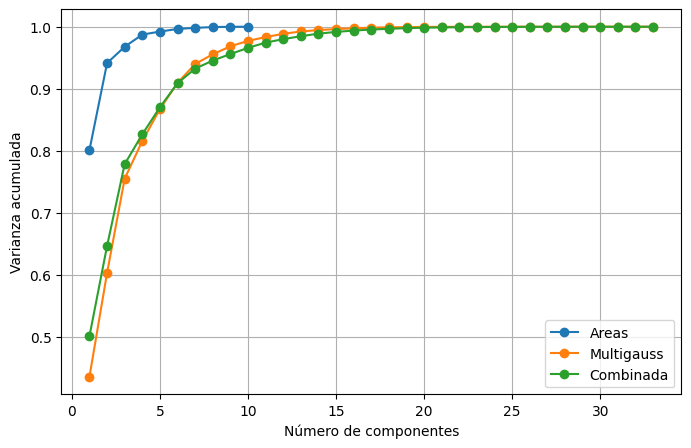

In [74]:
#Veamos una comparativa en grafica
plt.figure(figsize=(8,5))

for nombre, pca in [
    ("Areas", pca_areas),
    ("Multigauss", pca_multigauss),
    ("Combinada", pca_total)
]:

    plt.plot(
        np.arange(
            1,
            len(pca.explained_variance_ratio_)+1
        ),
        np.cumsum(
            pca.explained_variance_ratio_
        ),
        "o-",
        label=nombre
    )

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid()
plt.show()

In [75]:
# Con la grafica podemos observas que para alcanzar una varianza acumulada del 90% ocupamos
# parea areas 2 componentes, multigauss 6 componentes y combinada aproximadamente entre 5 o 6 componentes.
# Ahora que reducimos variables y conocemos nuestras bases podemos comenzar con la red

# Como la  red no entiende texto, codificamos etiquetas
encoder=LabelEncoder()

y_areas_num=encoder.fit_transform(y_areas)
print(encoder.classes_)
print(y_areas_num)

['anemico' 'asume' 'sano']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1]


In [76]:
#Ahora creamos PCA reducidos para cada una de las bases
#Area FTIR
pca_areas_red=PCA(n_components=2)
X_areas_red=pca_areas_red.fit_transform(X_scaled_areas)
print(X_areas_red.shape)

#Multigauss
pca_multigauss_red=PCA(n_components=6)
X_multigauss_red=pca_multigauss_red.fit_transform(X_scaled_multigauss)
print(X_multigauss_red.shape)

#Combinada
pca_total_red=PCA(n_components=10)
X_total_red=pca_total_red.fit_transform(X_scaled_total)
print(X_total_red.shape)


(33, 2)
(33, 6)
(33, 10)


In [77]:
#Ahora como tenemos 33 muestras no nos convienehacer una seperacion con
# con train_test_split porque perderamios demasiadas muestras , entonces obtamos
# por hacer validacion cruzada.
def evaluar_modelo(X, y, nombre_base, n_splits=5):

    # Definimos la red neuronal, iniciamos por una sencilla
    modelo = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation='relu',
        solver='adam',
        max_iter=5000,
        random_state=1
    )

    # Hacemos validación cruzada
    #Aqui la funcion stratifiedkFold divide las 33 muestras en el numero de
    #divisiones que le indiquemos en el caso de area son  5, esto nos da aprox 6 o 7
    #muestras por Fold. El Fold se divide en 5, donde el Fold 1 entrena con
    #26 muestras en este caso y prueba con 7 muestras, despues el Fold 2
    #cambia las muestras entrena con otras 26 y prueba con otras 7 y asi hasta
    # y asi hasta el 5to Fold, asi es que todas las muestras son usadas para
    # prueba alguna vez.
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=1
    )

    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    print(f"\n===== {nombre_base} =====")
    print("Accuracy por fold:", scores)
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())

    return scores.mean(), scores.std(), scores, modelo, cv

In [78]:
#Ahora definimos para Areas de FTIR
acc_areas, std_areas, scores_areas, modelo_areas, cv_areas = evaluar_modelo(X_areas_red, y_areas_num, "Areas de FTIR")


===== Areas de FTIR =====
Accuracy por fold: [0.85714286 0.71428571 0.85714286 0.83333333 0.83333333]
Accuracy promedio: 0.819047619047619
Desviación estándar: 0.053452248382484864


In [79]:
# Seguimos Multigauss
acc_multigauss, std_multigauss, scores_multigauss, modelo_multigauss, cv_multigauss = evaluar_modelo(X_multigauss_red, y_areas_num, "Multigauss")


===== Multigauss =====
Accuracy por fold: [0.57142857 0.57142857 0.71428571 0.83333333 0.83333333]
Accuracy promedio: 0.7047619047619048
Desviación estándar: 0.11722412976277309


In [80]:
#Finalmente la combinada
acc_total, std_total, scores_total, modelo_total, cv_total = evaluar_modelo(X_total_red, y_areas_num, "Combinada")


===== Combinada =====
Accuracy por fold: [0.85714286 0.42857143 0.71428571 0.83333333 0.83333333]
Accuracy promedio: 0.7333333333333334
Desviación estándar: 0.16035674514745465


In [81]:
#Armamos una tabla que nos resuma
resultados = pd.DataFrame({
    'Base': ['Areas FTIR', 'Multigauss', 'Combinada'],
    'Accuracy promedio': [acc_areas, acc_multigauss, acc_total],
    'Desviación estándar': [std_areas, std_multigauss, std_total]
})

resultados

,Base,Accuracy promedio,Desviación estándar
0,Areas FTIR,0.819048,0.053452
1,Multigauss,0.704762,0.117224
2,Combinada,0.733333,0.160357


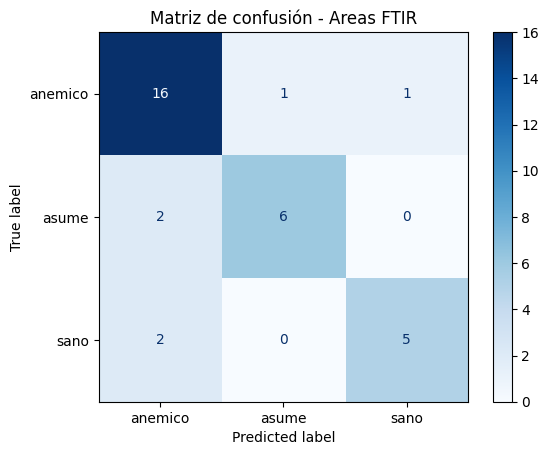

In [82]:
#Grafiquemos
#primero definimos lo que sera la prediccion cruzada usando la mejor base
y_pred = cross_val_predict(
    modelo_areas,
    X_areas_red,
    y_areas_num,
    cv=cv_areas
)

#Definimos la matriz de confusion
cm = confusion_matrix(
    y_areas_num,
    y_pred
)

cm
#Graficamos
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Areas FTIR"
)

plt.show()

In [83]:
#Para una red neuronal de 10 neuronas y una capa

#La matriz de muestra que la red neuronal identifico correctamente el 88.9%
#de las muestras anemicas, 75% de los autodeclarados y el 71.4% de las
#muestras sanas. Los errores de clasificación se concentraron entre el
#grupo anemico y autodeclarado, mientras que entre sano y autodeclarado no
# se muestran confusiones Este comportamiento es consistente con los resultados
#obtenidos previamente mediante susceptibilidad magnética y e analisis estadistico
#mostrado en el proyecto1, donde los valores del grupo autodeclarado mostraron una
# mayor similitud con los anemicos.

# Ahora aunque las variables derivadas deconvolucion gaussiana contiene una
# descripcion mas detallada sobre la estructura proteica secundaria,
#los mejores resultados de clasificacion se obtuvieron utilizando las
# areas FTIR integradas. Esto sugiere que, para el tamaño de muestra
#disponible, las diferencias globales en intensidad espectral constituyen
# un descriptor mas robusto.

#Exploraremos ahora hiperparametros, para ver que  estructura nos da mejores
# resultados, igualemente checaremos funciones de activacion

#Definimos las arquitecturas a probar con esta misma definicion de red

arquitecturas = [
    (3,),
    (5,),
    (10,),
    (15,),
    (20,),
    (10, 2),
    (10, 5),
    (10, 10),
    (15, 2),
    (15, 5),
    (20, 10),
]




In [84]:
#Aplicamos el mismo codigo
def evaluar_arquitecturas(X, y, nombre_base, arquitecturas, n_splits=5):

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=1
    )

    resultados = []

    for arquitectura in arquitecturas:

        modelo = MLPClassifier(
            hidden_layer_sizes=arquitectura,
            activation="relu",
            solver="adam",
            max_iter=5000,
            random_state=1
        )

        scores = cross_val_score(
            modelo,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )

        resultados.append({
            "Base": nombre_base,
            "Arquitectura": str(arquitectura),
            "Accuracy promedio": scores.mean(),
            "Desviación estándar": scores.std()
        })

    return pd.DataFrame(resultados)

In [85]:
arquitecturas = [
    (3,),
    (5,),
    (10,),
    (15,),
    (20,),
    (10, 2),
    (10, 5),
    (10, 10),
    (15, 2),
    (15, 5),
    (20, 10),
]



#Aplicamos a las 3 bases
res_areas = evaluar_arquitecturas(
    X_areas_red,
    y_areas_num,
    "Áreas FTIR",
    arquitecturas
)

res_multigauss = evaluar_arquitecturas(
    X_multigauss_red,
    y_areas_num,
    "Multigauss",
    arquitecturas
)

res_total = evaluar_arquitecturas(
    X_total_red,
    y_areas_num,
    "Combinada",
    arquitecturas
)

In [87]:
# Veamos una tabla con los resultados
resultados_arquitecturas = pd.concat(
    [res_areas, res_multigauss, res_total],
    ignore_index=True
)

resultados_arquitecturas

,Base,Arquitectura,Accuracy promedio,Desviación estándar
0,Áreas FTIR,"(3,)",0.847619,0.091101
1,Áreas FTIR,"(5,)",0.761905,0.107539
2,Áreas FTIR,"(10,)",0.819048,0.053452
3,Áreas FTIR,"(15,)",0.785714,0.150585
4,Áreas FTIR,"(20,)",0.814286,0.117031
5,Áreas FTIR,"(10, 2)",0.733333,0.096890
6,Áreas FTIR,"(10, 5)",0.790476,0.062814
7,Áreas FTIR,"(10, 10)",0.790476,0.110040
8,Áreas FTIR,"(15, 2)",0.580952,0.087287
9,Áreas FTIR,"(15, 5)",0.728571,0.106053


In [88]:
#Veamos de mejor accuracy a menor
resultados_arquitecturas.sort_values(
    by="Accuracy promedio",
    ascending=False
)

,Base,Arquitectura,Accuracy promedio,Desviación estándar
0,Áreas FTIR,"(3,)",0.847619,0.091101
2,Áreas FTIR,"(10,)",0.819048,0.053452
4,Áreas FTIR,"(20,)",0.814286,0.117031
7,Áreas FTIR,"(10, 10)",0.790476,0.110040
6,Áreas FTIR,"(10, 5)",0.790476,0.062814
10,Áreas FTIR,"(20, 10)",0.790476,0.062814
3,Áreas FTIR,"(15,)",0.785714,0.150585
1,Áreas FTIR,"(5,)",0.761905,0.107539
5,Áreas FTIR,"(10, 2)",0.733333,0.096890
12,Multigauss,"(5,)",0.733333,0.096890


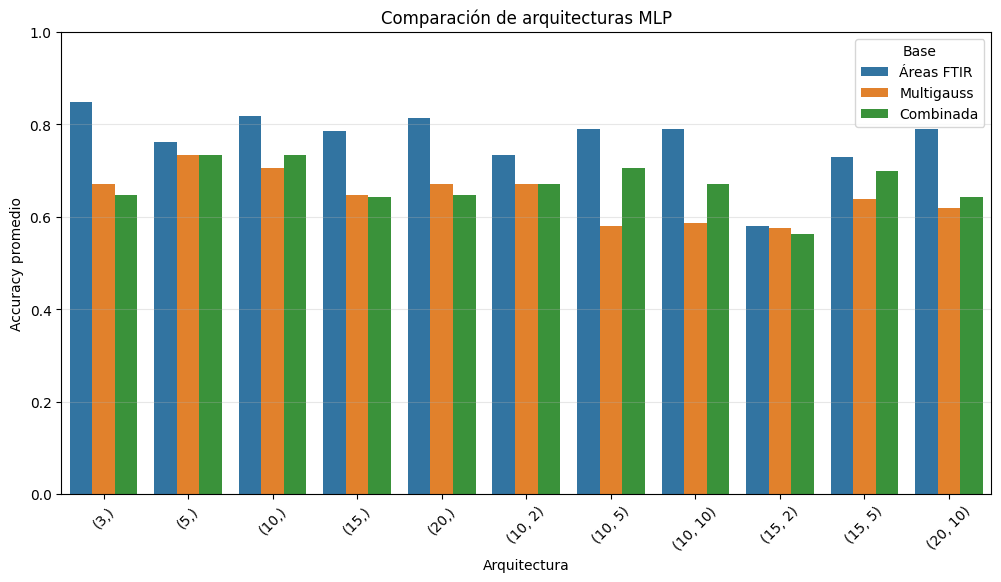

In [89]:
#Graficamos para ver el accuracy con respecto a la arquitectura
plt.figure(figsize=(12,6))

sns.barplot(
    data=resultados_arquitecturas,
    x="Arquitectura",
    y="Accuracy promedio",
    hue="Base"
)

plt.ylabel("Accuracy promedio")
plt.xlabel("Arquitectura")
plt.title("Comparación de arquitecturas MLP")
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [90]:
#Aqui chacamos cuales son la majerose con respecto a la  accuracy y desv,std
mejores = (
    resultados_arquitecturas
    .sort_values(
        "Accuracy promedio",
        ascending=False
    )
    .groupby("Base")
    .first()
    .reset_index()
)

mejores

,Base,Arquitectura,Accuracy promedio,Desviación estándar
0,Combinada,"(5,)",0.733333,0.096890
1,Multigauss,"(5,)",0.733333,0.096890
2,Áreas FTIR,"(3,)",0.847619,0.091101


In [91]:
# Como podemos ver los mejores resultados se obtuvieron con arquitecturas simples. En particular,
# la red neruonal de 3 neuronas y 1 capa  obtuvo una exactitud promedio del 84.8 % utilizando
#las areas FTIR.El incremento en la complejidad de la red no produjo mejoras edujo el desempeño,
# probablemente debido al reducido numero de muestras disponibles y al incremento en el numero de
#parametros libres.

#Ahora para explorar funciones de activacion y neuronas, usaremos la libreria tensor flow
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [92]:
#Preparamos las etiquetas para tensor flow
y_cat = to_categorical(y_areas_num)

print(y_areas_num[:10])
print(y_cat[:10])

[0 0 0 0 0 0 0 0 0 0]
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [93]:
#Consruimos la funcion general
def crear_modelo_tf(input_dim, arquitectura=(3,), activaciones=None):

    if activaciones is None:
        activaciones = ["relu"] * len(arquitectura)

    modelo = Sequential()

    # Primera capa oculta
    modelo.add(
        Dense(
            arquitectura[0],
            activation=activaciones[0],
            input_shape=(input_dim,)
        )
    )

    # Capas ocultas adicionales
    for neuronas, act in zip(arquitectura[1:], activaciones[1:]):
        modelo.add(
            Dense(
                neuronas,
                activation=act
            )
        )

    # Capa de salida para 3 clases
    modelo.add(
        Dense(
            3,
            activation="softmax"
        )
    )

    modelo.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [94]:
#Ahora construimos la funcion de validacion cruzada por tensor flow
def evaluar_tensorflow(X, y, nombre_base, arquitectura=(3,), activaciones=None, n_splits=5, epochs=200):

    y_cat = to_categorical(y)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=1
    )

    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y_cat[train_idx]
        y_test = y_cat[test_idx]

        # Para que cada fold empiece limpio
        tf.keras.backend.clear_session()

        modelo = crear_modelo_tf(
            input_dim=X.shape[1],
            arquitectura=arquitectura,
            activaciones=activaciones
        )

        modelo.fit(
            X_train,
            y_train,
            epochs=epochs,
            verbose=0
        )

        y_pred_prob = modelo.predict(
            X_test,
            verbose=0
        )

        y_pred = np.argmax(
            y_pred_prob,
            axis=1
        )

        y_true = np.argmax(
            y_test,
            axis=1
        )

        acc = accuracy_score(
            y_true,
            y_pred
        )

        scores.append(acc)

        print(f"Fold {fold}: accuracy = {acc:.3f}")

    scores = np.array(scores)

    print(f"\n===== {nombre_base} =====")
    print("Arquitectura:", arquitectura)
    print("Activaciones:", activaciones)
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())

    return scores.mean(), scores.std(), scores

In [95]:
#Aplicamos a base de Area FTIR
acc_tf_areas, std_tf_areas, scores_tf_areas = evaluar_tensorflow(
    X_areas_red,
    y_areas_num,
    "Áreas FTIR",
    arquitectura=(3,),
    activaciones=["relu"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.143


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3: accuracy = 0.714


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: accuracy = 0.500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: accuracy = 0.667

===== Áreas FTIR =====
Arquitectura: (3,)
Activaciones: ['relu']
Accuracy promedio: 0.4904761904761904
Desviación estándar: 0.202926435739643


In [97]:
# Multigauss
acc_tf_multi, std_tf_multi, scores_tf_multi = evaluar_tensorflow(
    X_multigauss_red,
    y_areas_num,
    "Multigauss",
    arquitectura=(5,),
    activaciones=["relu"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.571


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.571


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3: accuracy = 0.143


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: accuracy = 0.333


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: accuracy = 0.500

===== Multigauss =====
Arquitectura: (5,)
Activaciones: ['relu']
Accuracy promedio: 0.42380952380952375
Desviación estándar: 0.16523191974188067


In [100]:
#Combinado
acc_tf_total, std_tf_total, scores_tf_total = evaluar_tensorflow(
    X_total_red,
    y_areas_num,
    "Combinada",
    arquitectura=(5,),
    activaciones=["relu"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.714


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.286


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3: accuracy = 0.286


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: accuracy = 0.667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: accuracy = 0.667

===== Combinada =====
Arquitectura: (5,)
Activaciones: ['relu']
Accuracy promedio: 0.5238095238095237
Desviación estándar: 0.19518001458970666


In [101]:
activaciones_tf = ["relu", "tanh", "sigmoid"]

resultados_tf = []

for act in activaciones_tf:

    acc, std, scores = evaluar_tensorflow(
        X_areas_red,
        y_areas_num,
        f"Áreas FTIR - {act}",
        arquitectura=(3,),
        activaciones=[act],
        epochs=200
    )

    resultados_tf.append({
        "Base": "Áreas FTIR",
        "Arquitectura": "(3,)",
        "Activación": act,
        "Accuracy promedio": acc,
        "Desviación estándar": std
    })

resultados_tf = pd.DataFrame(resultados_tf)

resultados_tf

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.429


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: accuracy = 0.500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: accuracy = 0.333

===== Áreas FTIR - sigmoid =====
Arquitectura: (3,)
Activaciones: ['sigmoid']
Accuracy promedio: 0.4523809523809524
Desviación estándar: 0.1974899176507402


,Base,Arquitectura,Activación,Accuracy promedio,Desviación estándar
0,Áreas FTIR,"(3,)",relu,0.614286,0.161062
1,Áreas FTIR,"(3,)",tanh,0.404762,0.179442
2,Áreas FTIR,"(3,)",sigmoid,0.452381,0.197490
